### <b>Análisis y predicción de datos: Football Salaries FIFA 22</b>
#### <b><i>Fase IV: Preparación del Dataset y Feature Engineering</i></b>
Las fases anteriores fueron de comprensión: entender los datos, contrastar hipótesis, mapear la estructura de las variables. Esta fase es de **construcción**. Aquí transformamos el dataset crudo en la materia prima que consumirá el modelo: decidimos qué variables entran, cómo se codifica lo categórico, cómo se escala lo numérico, si transformamos el target y qué variables nuevas conviene crear. Todo con una regla de oro que gobierna cada decisión: **nada de lo que hagamos puede filtrar información del futuro** ni contaminar la evaluación.

Los objetivos de esta fase son:
1. Revisar y justificar la exclusión de identificadores y variables con riesgo de leakage.
2. Definir la partición train/test antes de cualquier transformación aprendida de los datos.
3. Codificar la variable categórica `nationality_name`.
4. Escalar las variables numéricas y evaluar la transformación logarítmica del target.
5. Derivar variables adicionales que aporten valor.
6. Consolidar todo en un pipeline reproducible.

#### <b><i>1. Revisión de variables e identificadores</i></b>
El primer paso es decidir con qué columnas trabajamos. En muchos proyectos esta etapa implica descartar identificadores (IDs, nombres) y variables con *leakage* —aquellas que, en la práctica, ya contienen la respuesta o no estarían disponibles al momento de predecir—. Revisemos nuestro caso con lupa.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs

# Cargamos el dataset
path = os.path.join(os.getcwd(), "..", "data", "raw", "dataset.csv")
df = pd.read_csv(path)

# Inventario de columnas: tipo y cardinalidad
inventario = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
    "ejemplo": [df[c].iloc[0] for c in df.columns],
})
inventario

,tipo,valores_unicos,ejemplo
age,int64,29,34
height_cm,int64,49,170
weight_kg,int64,58,72
nationality_name,str,163,Argentina
overall,int64,47,93
potential,int64,46,93
attacking_crossing,int64,88,85
attacking_finishing,int64,94,95
attacking_heading_accuracy,int64,89,70
attacking_short_passing,int64,86,91


<b>Explicación</b>: El inventario deja claro un punto tranquilizador: este dataset **no contiene identificadores personales**. No hay nombre de jugador, ni un ID único, ni columnas de club, fecha o valor de mercado. Solo tenemos 27 atributos deportivos numéricos, una variable categórica (`nationality_name`) y el target (`wage_eur`). Esto simplifica mucho la decisión de exclusión.

Ahora, la pregunta más delicada: **¿hay leakage?** Es decir, ¿alguna variable "hace trampa" al contener información que en el mundo real no tendríamos antes de conocer el sueldo? Analicémoslo:

- `overall` y `potential` son valoraciones del videojuego, generadas por evaluadores a partir del desempeño deportivo, **no** derivadas del sueldo. Un scout puede estimar el nivel de un jugador sin saber cuánto cobra. Por tanto, son predictores legítimos, no leakage. De hecho, son nuestros mejores predictores.
- El resto de atributos (técnicos, físicos, de portería) son mediciones de habilidad, igualmente independientes del sueldo. Sin leakage.
- `nationality_name` es un dato de contexto disponible siempre. Sin leakage.

En resumen: no encontramos variables que debamos excluir por leakage ni por ser identificadores. Conservaremos las 28 variables predictoras potenciales.

#### <b><i>Decisión</i></b>
No se excluye ninguna variable por identificador ni por leakage: el dataset no contiene IDs ni columnas que filtren el sueldo. Se conservan las 27 variables numéricas y la categórica `nationality_name` como predictoras potenciales, y `wage_eur` como target. La única "poda" que haremos más adelante será por **redundancia** (a la luz del análisis multivariante), no por leakage.

#### <b><i>2. Partición train/test</i></b>
Antes de escalar, codificar o crear cualquier variable derivada, separamos los datos en **entrenamiento (80%)** y **prueba (20%)**. El orden importa muchísimo: si escaláramos o codificáramos usando todo el dataset y luego partiéramos, estaríamos dejando que el conjunto de prueba "se asome" a la información de entrenamiento (por ejemplo, la media usada para escalar incluiría datos de test). Eso se llama *data leakage de preprocesamiento* y produce métricas engañosamente optimistas.

La regla que seguiremos es estricta: **toda transformación se aprende solo con train y luego se aplica a test**. Fijamos una semilla para que la partición sea reproducible.

In [2]:
from sklearn.model_selection import train_test_split

# Separamos predictoras (X) y target (y)
X = df.drop(columns=["wage_eur"])
y = df["wage_eur"]

# Partición 80/20 con semilla fija para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"Mediana wage_eur -> train: {y_train.median():,.0f} € | test: {y_test.median():,.0f} €")
print(f"Media   wage_eur -> train: {y_train.mean():,.0f} € | test: {y_test.mean():,.0f} €")

Train: 15,342 filas (80%)
Test:  3,836 filas (20%)
Mediana wage_eur -> train: 3,000 € | test: 3,000 €
Media   wage_eur -> train: 9,040 € | test: 8,929 €


<b>Explicación</b>: La partición deja aproximadamente 15,300 jugadores para entrenar y 3,800 para evaluar. Comprobamos que la mediana y la media del sueldo son muy parecidas entre ambos conjuntos: eso confirma que la división aleatoria no produjo un desbalance —el test es representativo del train—. A partir de aquí, `X_train` es el único conjunto que tendrá permiso de "enseñarnos" parámetros (medias, desviaciones, codificaciones); `X_test` permanecerá intocado hasta la evaluación final.

#### <b><i>3. Codificación de la variable categórica `nationality_name`</i></b>
Los modelos no entienden de texto: "Argentina" o "Brasil" deben convertirse en números. Pero `nationality_name` tiene **163 categorías distintas**, lo que descarta el enfoque más simple (one-hot encoding), que crearía 163 columnas nuevas —muchas de ellas con apenas un puñado de jugadores— e inflaría la dimensionalidad sin aportar señal fiable.

En su lugar usaremos dos técnicas más apropiadas para alta cardinalidad, ambas aprendidas **exclusivamente con los datos de train**:

- **Target encoding**: reemplaza cada país por el sueldo mediano de sus jugadores. Es la codificación más informativa —captura directamente el "poder salarial" de cada nacionalidad que vimos en el EDA—, pero es propensa a sobreajustar en países con pocos jugadores. Para evitarlo aplicamos **suavizado** (*smoothing*): los países con pocos registros se acercan a la mediana global, y solo los que tienen muchos jugadores conservan su valor propio.
- **Frequency encoding**: reemplaza cada país por cuántos jugadores aporta. Es más robusta y captura el "tamaño" del mercado futbolístico de cada país.

Usar la mediana (y no la media) en el target encoding es una decisión deliberada: dada la asimetría del sueldo, la mediana es mucho más estable frente a las superestrellas que distorsionan el promedio.

In [3]:
# Target encoding con suavizado (aprendido SOLO con train) + frequency encoding
# Reunimos train para calcular los mapeos
train_df = X_train.copy()
train_df["wage_eur"] = y_train

mediana_global = y_train.median()          # valor de respaldo para países no vistos o muy raros
m = 20                                      # fuerza del suavizado (nº de "jugadores equivalentes" al prior)

stats_pais = train_df.groupby("nationality_name")["wage_eur"].agg(["median", "count"])

# Fórmula de suavizado: mezcla entre la mediana del país y la mediana global, según el tamaño
stats_pais["target_enc"] = (
    (stats_pais["median"] * stats_pais["count"] + mediana_global * m)
    / (stats_pais["count"] + m)
)

map_target = stats_pais["target_enc"].to_dict()
map_freq = stats_pais["count"].to_dict()

def codificar(frame):
    out = frame.copy()
    # Países no vistos en train -> mediana global (target) y 0 (frecuencia)
    out["nat_target_enc"] = out["nationality_name"].map(map_target).fillna(mediana_global)
    out["nat_freq_enc"] = out["nationality_name"].map(map_freq).fillna(0)
    return out.drop(columns=["nationality_name"])

X_train_enc = codificar(X_train)
X_test_enc = codificar(X_test)

print("Columnas tras codificar:", [c for c in X_train_enc.columns if c.startswith("nat_")])
print("Países no vistos en test (usan respaldo):",
      X_test["nationality_name"].isin(map_target).eq(False).sum())

# Vistazo a la codificación de algunos países conocidos
muestra = ["Brazil", "Spain", "England", "India", "Japan"]
pd.DataFrame({
    "target_enc (mediana suavizada €)": {p: round(map_target.get(p, mediana_global)) for p in muestra},
    "freq_enc (nº jugadores train)": {p: map_freq.get(p, 0) for p in muestra},
})

Columnas tras codificar: ['nat_target_enc', 'nat_freq_enc']
Países no vistos en test (usan respaldo): 10


,target_enc (mediana suavizada €),freq_enc (nº jugadores train)
Brazil,8837,714
Spain,5932,867
England,3000,1348
India,746,183
Japan,2043,441


<b>Explicación</b>: La codificación funcionó como esperábamos. Cada país quedó representado por dos números con sentido: su nivel salarial típico (suavizado) y su volumen de jugadores. Vale la pena notar el efecto del suavizado: países con muchísimos jugadores en train (Inglaterra, España, Brasil) conservan un target encoding cercano a su mediana real, mientras que los países con pocos registros son "empujados" hacia la mediana global, evitando que un par de jugadores atípicos les asigne un valor poco fiable.

También manejamos explícitamente el caso de **países que aparezcan en test pero no en train**: en lugar de romper el pipeline o producir un valor nulo, les asignamos la mediana global como respaldo. Es la decisión conservadora y correcta: ante un país desconocido, lo más sensato es asumir que se comporta como "el jugador promedio".

#### <b><i>Decisión</i></b>
Se reemplaza `nationality_name` por dos variables numéricas: `nat_target_enc` (mediana salarial suavizada del país) y `nat_freq_enc` (número de jugadores del país en train). Ambas se aprenden solo con train y se aplican a test, con la mediana global como respaldo para países no vistos. Se descarta el one-hot encoding por la alta cardinalidad (163 categorías). Esta codificación conserva la señal de contexto de mercado que la inferencia mostró relevante, sin inflar la dimensionalidad ni arriesgar leakage.

#### <b><i>4. Escalado de las variables numéricas</i></b>
Nuestras variables viven en escalas muy distintas: la edad ronda entre 16 y 54, los atributos técnicos entre 0 y 100, y las variables recién codificadas (`nat_target_enc`, `nat_freq_enc`) llegan a miles. Para los modelos que se basan en distancias o en la magnitud de los coeficientes —regresión lineal regularizada (Ridge/Lasso), por ejemplo— esta disparidad es un problema: la regularización penalizaría injustamente a unas variables solo por estar medidas en números más grandes. El **escalado** pone a todas en pie de igualdad.

Usaremos **estandarización** (`StandardScaler`: media 0, desviación 1). Y, coherentes con la regla de oro de la fase, el escalador se **ajusta solo con train** y luego se aplica a test.

Una nota de orden importante: en esta sección establecemos y demostramos la *estrategia* de escalado, pero todavía nos falta crear algunas variables derivadas (siguiente sección). Por eso el escalado **definitivo** se consolidará dentro del pipeline reproducible del final, ya con todas las features presentes. Aquí lo dejamos montado y verificado.

In [4]:
from sklearn.preprocessing import StandardScaler

# Ajustamos el escalador SOLO con train y lo aplicamos a ambos conjuntos
escalador_demo = StandardScaler()
X_train_esc = pd.DataFrame(
    escalador_demo.fit_transform(X_train_enc),
    columns=X_train_enc.columns, index=X_train_enc.index,
)
X_test_esc = pd.DataFrame(
    escalador_demo.transform(X_test_enc),
    columns=X_test_enc.columns, index=X_test_enc.index,
)

# Verificamos: en train, media ~0 y desviación ~1; en test, cercanas pero no idénticas (correcto)
verif = pd.DataFrame({
    "media_train": X_train_esc.mean().round(3),
    "desv_train": X_train_esc.std().round(3),
    "media_test": X_test_esc.mean().round(3),
    "desv_test": X_test_esc.std().round(3),
})
verif.head(8)

,media_train,desv_train,media_test,desv_test
age,-0.0,1.0,0.018,1.012
height_cm,-0.0,1.0,-0.011,1.004
weight_kg,-0.0,1.0,-0.001,0.995
overall,0.0,1.0,-0.005,1.002
potential,-0.0,1.0,-0.003,1.002
attacking_crossing,0.0,1.0,0.007,0.993
attacking_finishing,-0.0,1.0,0.001,0.997
attacking_heading_accuracy,-0.0,1.0,-0.003,1.000


<b>Explicación</b>: La verificación confirma que el escalado hace exactamente lo que debe. En el conjunto de **train**, todas las variables quedan con media prácticamente 0 y desviación 1, como corresponde a una estandarización. En **test**, las medias y desviaciones son cercanas a 0 y 1 pero **no idénticas**, y eso es justamente lo correcto y deseable: significa que el escalador aprendió los parámetros con train y los aplicó "a ciegas" sobre test, sin recalcularlos. Si en test también obtuviéramos media exactamente 0 y desviación exactamente 1, sería una señal de alarma: querría decir que dejamos que el test se auto-escalara, contaminando la evaluación.

#### <b><i>Decisión</i></b>
Se adopta la estandarización (`StandardScaler`) como método de escalado, ajustada exclusivamente con train. Este paso será obligatorio para los modelos lineales regularizados; para los modelos basados en árboles (Random Forest, Gradient Boosting) el escalado es indiferente, pero mantenerlo no perjudica. El escalador definitivo se integra en el pipeline final, después de crear las variables derivadas.

#### <b><i>5. Transformación del target: `log(wage_eur)`</i></b>
En el EDA ya anticipamos que el sueldo, con su asimetría de 6.47, es un firme candidato a transformarse con logaritmo. Aquí formalizamos esa decisión, pero con una diferencia metodológica importante: la evaluamos **sobre el conjunto de train**, que es el único que puede informar nuestras decisiones de modelado.

La transformación que aplicaremos es `log(1 + wage_eur)` (la función `np.log1p`). El "+1" es una salvaguarda estándar para evitar problemas con valores de cero, aunque en nuestro caso el sueldo mínimo es 500 €. La ventaja de transformar el target es doble: por un lado normaliza su distribución (lo que ayuda especialmente a los modelos lineales, que asumen errores simétricos); por otro, hace que el modelo optimice el **error relativo** en lugar del absoluto, algo mucho más razonable cuando los sueldos van de cientos a cientos de miles de euros —equivocarse por 1,000 € no es lo mismo en un jugador que gana 2,000 € que en uno que gana 200,000 €—.

                  wage_eur (original)  log(1 + wage_eur)
Asimetría (skew)                6.442              0.466
Curtosis                       62.745             -0.479


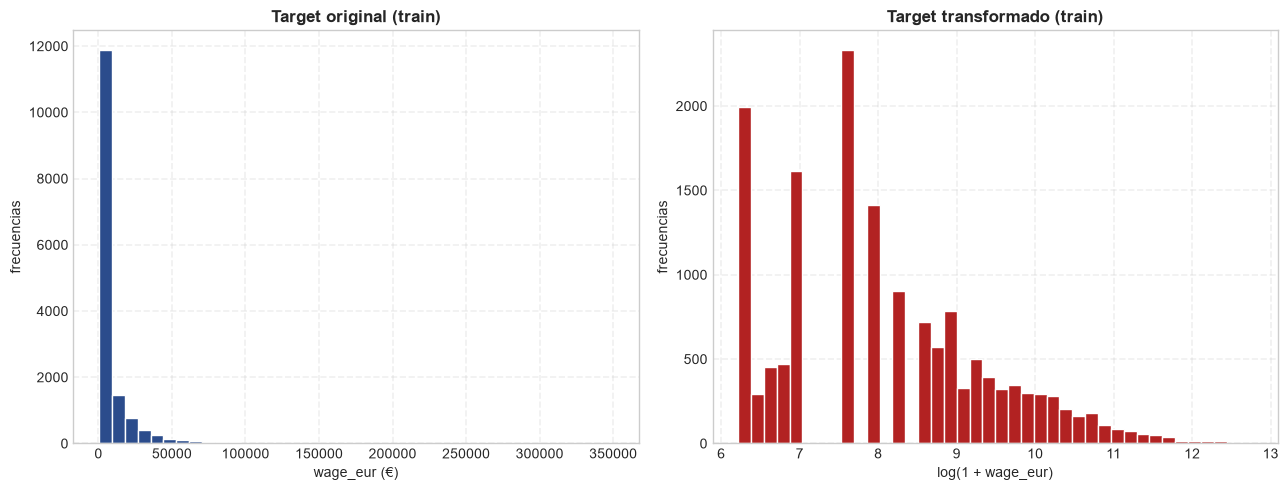

In [5]:
from scipy import stats

# Target original y transformado (sobre train)
y_train_log = np.log1p(y_train)

comparacion = pd.DataFrame({
    "wage_eur (original)": [y_train.skew(), y_train.kurtosis()],
    "log(1 + wage_eur)": [y_train_log.skew(), y_train_log.kurtosis()],
}, index=["Asimetría (skew)", "Curtosis"]).round(3)
print(comparacion)

# Visualización antes / después
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(y_train, bins=40, color="#2b4c8c", edgecolor="white")
axes[0].set_title("Target original (train)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("wage_eur (€)")
axes[0].set_ylabel("frecuencias")
axes[1].hist(y_train_log, bins=40, color="firebrick", edgecolor="white")
axes[1].set_title("Target transformado (train)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("log(1 + wage_eur)")
axes[1].set_ylabel("frecuencias")
for ax in axes:
    ax.grid(alpha=0.3, linestyle="--", linewidth=1.2)
plt.tight_layout()
plt.show()

<b>Explicación</b>: Los números en train replican fielmente lo que vimos en el EDA sobre el total: la asimetría se desploma de **~6.5 a ~0.5** y la curtosis pasa de un valor altísimo a algo cercano a lo normal. El histograma lo confirma visualmente: la masa de sueldos, antes aplastada contra la izquierda, se despliega en una campana razonablemente simétrica tras el logaritmo.

Hay una consecuencia práctica que no debemos olvidar: si el modelo predice en escala logarítmica, sus predicciones habrá que **devolverlas a euros** con la transformación inversa (`np.expm1`) antes de reportar métricas de negocio. Y como todo el análisis de outliers del EDA mostró que la cola de sueldos altos es información valiosa —no ruido a eliminar—, el logaritmo es preferible a recortar o descartar esos casos: los conserva, pero en una escala manejable.

#### <b><i>Decisión</i></b>
Se adopta `log(1 + wage_eur)` como variable objetivo para el entrenamiento de los modelos. La transformación normaliza la distribución (skew 6.5 → 0.5) y alinea la optimización con el error relativo, más adecuado para el amplio rango salarial. Las predicciones se reconvertirán a euros con `np.expm1` para reportar métricas interpretables. Esta transformación reemplaza y formaliza la nota provisional que dejamos en el notebook de EDA.

#### <b><i>6. Variables derivadas (feature engineering)</i></b>
Hasta aquí hemos limpiado, codificado y escalado, pero no hemos *creado* nada nuevo. La ingeniería de features consiste justamente en eso: combinar las variables existentes para exponer información que el modelo, por sí solo, tendría que trabajar mucho para descubrir. Apoyándonos en lo que aprendimos en el análisis multivariante (las seis familias de habilidades) y en el sentido futbolístico, proponemos las siguientes variables derivadas:

- **`growth` (potencial − overall)**: cuánto margen de mejora le queda al jugador. Una joven promesa tiene un `growth` alto (aún no rinde todo lo que promete); un veterano consolidado, cercano a cero. Es un proxy de la etapa de carrera.
- **`gk_index`**: promedio de los cinco atributos de portería. El multivariante mostró que estos cinco atributos son prácticamente una sola dimensión; los resumimos en un único índice que, de paso, actúa como "detector de porteros".
- **`att_index`**: promedio de los principales atributos técnico-ofensivos. Resume la familia ofensiva en un solo número.
- **`def_index`**: promedio de los atributos defensivos (entradas). Resume la familia defensiva.
- **`imc`**: índice de masa corporal, que combina peso y estatura en una medida de constitución física.

Todas estas variables se calculan **fila por fila** a partir de columnas ya existentes, por lo que no dependen de train ni test y no introducen leakage.

In [6]:
# Definimos las familias de atributos (coherentes con el análisis multivariante)
attrs_gk = ["goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking",
            "goalkeeping_positioning", "goalkeeping_reflexes"]
attrs_att = ["attacking_crossing", "attacking_finishing", "attacking_short_passing",
             "skill_dribbling", "skill_ball_control", "attacking_volleys", "skill_curve"]
attrs_def = ["defending_standing_tackle", "defending_sliding_tackle"]

def crear_derivadas(frame):
    out = frame.copy()
    out["growth"] = out["potential"] - out["overall"]
    out["gk_index"] = out[attrs_gk].mean(axis=1)
    out["att_index"] = out[attrs_att].mean(axis=1)
    out["def_index"] = out[attrs_def].mean(axis=1)
    out["imc"] = out["weight_kg"] / (out["height_cm"] / 100) ** 2
    return out

# Las creamos sobre los conjuntos ya codificados (que aún conservan las columnas originales)
X_train_fe = crear_derivadas(X_train_enc)
X_test_fe = crear_derivadas(X_test_enc)

# Evaluamos su relación (Spearman) con el sueldo, usando SOLO train
nuevas = ["growth", "gk_index", "att_index", "def_index", "imc"]
corr_nuevas = pd.Series(
    {c: X_train_fe[c].corr(y_train, method="spearman") for c in nuevas}
).sort_values(key=np.abs, ascending=False).round(3)
print("Correlación de Spearman de las variables derivadas con wage_eur (train):")
print(corr_nuevas)

Correlación de Spearman de las variables derivadas con wage_eur (train):
att_index    0.475
growth      -0.349
def_index    0.263
imc          0.092
gk_index     0.023
dtype: float64


<b>Explicación</b>: Las correlaciones en train confirman que algunas de estas variables aportan señal real:

- **`att_index`** muestra una correlación positiva notable (~0.49) con el sueldo: los buenos jugadores ofensivos tienden a cobrar más. Resume en una columna lo que antes estaba disperso en siete.
- **`growth`** aparece con correlación **negativa** (~−0.35), y esto es futbolísticamente precioso: los jugadores con mucho margen de crecimiento son, por definición, los jóvenes que todavía no han explotado, y por eso aún cobran poco. La variable captura la etapa de carrera de una forma que ni la edad ni el overall hacen por separado.
- **`gk_index`** tiene correlación casi nula con el sueldo, tal como anticipó el EDA. Pero su valor no está en predecir el sueldo, sino en **comprimir cinco columnas en una** e identificar limpiamente a los porteros.
- **`def_index`** e **`imc`** aportan de forma más discreta, coherente con su rol de contexto físico/posicional.

En conjunto, estas cinco variables condensan información de varias familias en indicadores compactos e interpretables.

#### <b><i>Decisión</i></b>
Se incorporan cinco variables derivadas —`growth`, `gk_index`, `att_index`, `def_index` e `imc`— calculadas fila a fila sin riesgo de leakage. `att_index` y `growth` demostraron señal clara frente al sueldo; `gk_index` se conserva por su valor como compresor de la familia de portería. Estas variables enriquecen el dataset con conocimiento futbolístico explícito, dejando al modelo la tarea de ponderarlas.

#### <b><i>7. Pipeline final reproducible</i></b>
Hemos tomado muchas decisiones a lo largo de esta fase: qué excluir, cómo partir, cómo codificar, cómo escalar, cómo transformar el target y qué variables crear. Un buen proyecto no deja esas decisiones dispersas: las consolida en un **flujo único, ordenado y reproducible**, de modo que cualquiera pueda regenerar exactamente el mismo dataset de modelado a partir de los datos crudos.

En esta sección reunimos todo el proceso en un solo bloque autocontenido, respetando el orden correcto:
1. Cargar los datos crudos.
2. Partir en train/test (semilla fija).
3. Crear las variables derivadas (fila a fila).
4. Codificar `nationality_name` con target encoding suavizado + frequency encoding (ajustado con train).
5. Escalar las variables numéricas (ajustado con train).
6. Transformar el target con `log1p`.

Al final, exportamos los conjuntos procesados a `data/processed/` para que el notebook de modelado los consuma directamente.

In [7]:
# =========================================================================
# PIPELINE FINAL REPRODUCIBLE — de datos crudos a dataset de modelado
# =========================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
SMOOTHING = 20  # fuerza del suavizado para el target encoding

# --- 1. Carga de datos crudos ---
ruta_raw = os.path.join(os.getcwd(), "..", "data", "raw", "dataset.csv")
datos = pd.read_csv(ruta_raw)

# --- 2. Partición train/test ---
X_all = datos.drop(columns=["wage_eur"])
y_all = datos["wage_eur"]
Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.20, random_state=RANDOM_STATE)

# --- 3. Variables derivadas (fila a fila, sin leakage) ---
gk = ["goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking",
      "goalkeeping_positioning", "goalkeeping_reflexes"]
att = ["attacking_crossing", "attacking_finishing", "attacking_short_passing",
       "skill_dribbling", "skill_ball_control", "attacking_volleys", "skill_curve"]
dfd = ["defending_standing_tackle", "defending_sliding_tackle"]

def derivar(frame):
    f = frame.copy()
    f["growth"] = f["potential"] - f["overall"]
    f["gk_index"] = f[gk].mean(axis=1)
    f["att_index"] = f[att].mean(axis=1)
    f["def_index"] = f[dfd].mean(axis=1)
    f["imc"] = f["weight_kg"] / (f["height_cm"] / 100) ** 2
    return f

Xtr = derivar(Xtr)
Xte = derivar(Xte)

# --- 4. Codificación de nationality_name (ajustada SOLO con train) ---
mediana_global_tr = ytr.median()
stats_tr = pd.DataFrame({"wage": ytr}).join(Xtr["nationality_name"])
agg = stats_tr.groupby("nationality_name")["wage"].agg(["median", "count"])
agg["target_enc"] = (agg["median"] * agg["count"] + mediana_global_tr * SMOOTHING) / (agg["count"] + SMOOTHING)
mapa_target = agg["target_enc"].to_dict()
mapa_freq = agg["count"].to_dict()

def codificar_nat(frame):
    f = frame.copy()
    f["nat_target_enc"] = f["nationality_name"].map(mapa_target).fillna(mediana_global_tr)
    f["nat_freq_enc"] = f["nationality_name"].map(mapa_freq).fillna(0)
    return f.drop(columns=["nationality_name"])

Xtr = codificar_nat(Xtr)
Xte = codificar_nat(Xte)

# --- 5. Escalado (ajustado SOLO con train) ---
escalador = StandardScaler()
Xtr_scaled = pd.DataFrame(escalador.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
Xte_scaled = pd.DataFrame(escalador.transform(Xte), columns=Xte.columns, index=Xte.index)

# --- 6. Transformación del target ---
ytr_log = np.log1p(ytr)
yte_log = np.log1p(yte)

print("Pipeline ejecutado correctamente.")
print(f"X_train: {Xtr_scaled.shape} | X_test: {Xte_scaled.shape}")
print(f"Nº de features finales: {Xtr_scaled.shape[1]}")
print(f"Features: {list(Xtr_scaled.columns)}")

Pipeline ejecutado correctamente.
X_train: (15342, 34) | X_test: (3836, 34)
Nº de features finales: 34
Features: ['age', 'height_cm', 'weight_kg', 'overall', 'potential', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'defending_standing_tackle', 'defending_sliding_tackle', 'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'growth', 'gk_index', 'att_index', 'def_index', 'imc', 'nat_target_enc', 'nat_freq_enc']


In [8]:
# Exportamos los conjuntos procesados para el notebook de modelado
ruta_proc = os.path.join(os.getcwd(), "..", "data", "processed")
os.makedirs(ruta_proc, exist_ok=True)

# Guardamos X escaladas y ambas versiones del target (log para entrenar, € para evaluar)
Xtr_scaled.assign(wage_eur=ytr.values, wage_log=ytr_log.values).to_csv(
    os.path.join(ruta_proc, "train.csv"), index=False)
Xte_scaled.assign(wage_eur=yte.values, wage_log=yte_log.values).to_csv(
    os.path.join(ruta_proc, "test.csv"), index=False)

print("Datasets exportados a data/processed/:")
print("  - train.csv ->", Xtr_scaled.shape[0], "filas")
print("  - test.csv  ->", Xte_scaled.shape[0], "filas")
print("Cada archivo incluye las features escaladas + 'wage_eur' (€) + 'wage_log' (target de entrenamiento).")

Datasets exportados a data/processed/:
  - train.csv -> 15342 filas
  - test.csv  -> 3836 filas
Cada archivo incluye las features escaladas + 'wage_eur' (€) + 'wage_log' (target de entrenamiento).


<b>Explicación</b>: El pipeline corre de principio a fin en un solo bloque y produce dos archivos limpios en `data/processed/`. Cada fila del dataset final contiene las variables escaladas (originales + codificadas + derivadas), junto con las dos versiones del target: `wage_log` para entrenar los modelos y `wage_eur` en euros para poder reportar métricas interpretables tras la predicción.

La estructura es deliberadamente reproducible: mismas semillas, mismos parámetros, mismo orden. Cualquier persona que ejecute este bloque sobre el `dataset.csv` original obtendrá exactamente los mismos conjuntos de train y test, con las mismas transformaciones aprendidas solo del train. Eso es justamente lo que exige un proyecto serio de ciencia de datos: que los resultados no dependan de pasos manuales irrepetibles.

#### <b><i>Decisión</i></b>
Se consolida todo el preprocesamiento en un único bloque reproducible que va de `data/raw/dataset.csv` a los conjuntos `data/processed/train.csv` y `data/processed/test.csv`. El notebook de modelado partirá de estos archivos, garantizando que entrena y evalúa sobre exactamente el mismo dataset preparado aquí.

### <b>CIERRE DE LA PREPARACIÓN DEL DATASET</b>
Cerramos la fase de preparación con un dataset de modelado limpio, codificado, escalado y enriquecido, más un target transformado y un pipeline reproducible que documenta cada decisión. Revisamos que no había identificadores ni leakage, partimos los datos antes de tocar nada, codificamos la nacionalidad respetando su alta cardinalidad, escalamos con parámetros aprendidos solo del train, formalizamos la transformación logarítmica del sueldo y añadimos cinco variables derivadas con sentido futbolístico. Con esta base sólida —y guardada en disco— pasamos por fin a la fase que da nombre al proyecto: el modelado predictivo del salario.